In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('apple_products_pricing_2020_2026.csv')

print("Shape of dataset:", df.shape)
df.info()


Shape of dataset: (80000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               80000 non-null  object 
 1   Platform           80000 non-null  object 
 2   Product_Category   80000 non-null  object 
 3   Model_Name         80000 non-null  object 
 4   Condition          80000 non-null  object 
 5   Launch_Price_USD   80000 non-null  int64  
 6   Launch_Price_INR   80000 non-null  int64  
 7   Current_Price_USD  80000 non-null  float64
 8   Current_Price_INR  80000 non-null  float64
 9   Discount_Pct       80000 non-null  float64
 10  Sale_Event         6649 non-null   object 
 11  Stock_Status       80000 non-null  object 
 12  Rating             80000 non-null  float64
 13  Reviews_Count      80000 non-null  int64  
dtypes: float64(4), int64(3), object(7)
memory usage: 8.5+ MB


#Rows, columns, data types, and missing values

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nData types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())
print("\nPercentage missing:\n", (df.isnull().sum() / len(df) * 100).round(2))


Number of rows: 80000
Number of columns: 14

Data types:
 Date                  object
Platform              object
Product_Category      object
Model_Name            object
Condition             object
Launch_Price_USD       int64
Launch_Price_INR       int64
Current_Price_USD    float64
Current_Price_INR    float64
Discount_Pct         float64
Sale_Event            object
Stock_Status          object
Rating               float64
Reviews_Count          int64
dtype: object

Missing values per column:
 Date                     0
Platform                 0
Product_Category         0
Model_Name               0
Condition                0
Launch_Price_USD         0
Launch_Price_INR         0
Current_Price_USD        0
Current_Price_INR        0
Discount_Pct             0
Sale_Event           73351
Stock_Status             0
Rating                   0
Reviews_Count            0
dtype: int64

Percentage missing:
 Date                  0.00
Platform              0.00
Product_Category      0.00

## Exploratory inspection — first, last, and random records

In [4]:
print("First 5 records:")
display(df.head())

print("\nLast 5 records:")
display(df.tail())

print("\nRandom 5 records:")
display(df.sample(5, random_state=42))


First 5 records:


,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.41,-1.6,NaN,In Stock,4.7,40
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.43,-1.7,NaN,Out of Stock,4.6,84
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.36,1.5,NaN,In Stock,4.4,110
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.70,0.9,NaN,In Stock,4.8,111
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.28,-1.7,NaN,In Stock,4.7,35



Last 5 records:


,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
79995,2026-07-31,Flipkart,iPhone,iPhone 17 128GB,New,849,83202,861.39,82894.76,-1.5,NaN,In Stock,4.7,1346
79996,2026-07-31,Flipkart,iPhone,iPhone 17 128GB,New,849,83202,832.50,81159.39,1.9,NaN,In Stock,4.7,802
79997,2026-07-31,Amazon,iPhone,iPhone 17 128GB,Renewed/Refurbished,849,83202,657.30,56336.73,22.6,NaN,In Stock,4.2,1020
79998,2026-07-31,Flipkart,iPhone,iPhone 17 128GB,Renewed/Refurbished,849,83202,709.49,61361.07,16.4,NaN,In Stock,3.9,710
79999,2026-07-31,Flipkart,iPhone,iPhone 17 128GB,New,849,83202,834.95,83035.30,1.7,NaN,Low Stock,4.8,1022



Random 5 records:


,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
47044,2025-04-11,Amazon,iPhone,iPhone 16 Pro 256GB,New,1099,107702,1097.47,107480.49,0.1,NaN,In Stock,4.3,1050
44295,2025-02-27,Amazon,iPad,iPad Pro 12.9-inch (M2) 256GB,New,1199,117502,1001.40,96246.04,16.5,NaN,In Stock,4.4,3983
74783,2026-05-21,Flipkart,iPhone,iPhone 15 128GB,Renewed/Refurbished,799,78302,432.79,36865.41,45.8,NaN,In Stock,4.4,1744
70975,2026-03-29,Amazon,iPhone,iPhone 16 Pro 256GB,New,1099,107702,999.85,97344.40,9.0,NaN,In Stock,4.8,1570
46645,2025-04-05,Flipkart,Watch,Apple Watch Series 9 (45mm),New,429,42042,329.26,32091.76,23.2,NaN,In Stock,4.5,2401


## Detect and handle missing values



In [5]:
df_clean = df.copy()

print("Missing before cleaning:\n", df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# Sale_Event is NaN when no sale was running -> fill with an explicit label
df_clean['Sale_Event'] = df_clean['Sale_Event'].fillna('No Sale')

print("\nMissing after cleaning:\n", df_clean.isnull().sum().sum(), "total missing values remain")
print("\nSale_Event value counts:\n", df_clean['Sale_Event'].value_counts())


Missing before cleaning:
 Sale_Event    73351
dtype: int64

Missing after cleaning:
 0 total missing values remain

Sale_Event value counts:
 Sale_Event
No Sale                  73351
Black Friday              2497
Big Billion Days          1579
Great Indian Festival     1504
Prime Day                 1069
Name: count, dtype: int64


## Identify and remove duplicate records

In [6]:
num_duplicates = df_clean.duplicated().sum()
print("Number of duplicate rows found:", num_duplicates)

df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df_clean.shape)


Number of duplicate rows found: 0
Shape after removing duplicates: (80000, 14)


## Detect outliers using IQR and Z-score, visualize with box plots

We check `Current_Price_USD`, `Discount_Pct`, and `Reviews_Count`.


In [7]:
def iqr_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)], lower, upper

price_outliers, price_lower, price_upper = iqr_outliers(df_clean['Current_Price_USD'])
reviews_outliers, reviews_lower, reviews_upper = iqr_outliers(df_clean['Reviews_Count'])

print(f"Current_Price_USD: {len(price_outliers)} outliers (bounds: {price_lower:.2f} to {price_upper:.2f})")
print(f"Reviews_Count: {len(reviews_outliers)} outliers (bounds: {reviews_lower:.2f} to {reviews_upper:.2f})")

# Z-score method for comparison
from scipy import stats
z_scores = np.abs(stats.zscore(df_clean['Current_Price_USD']))
z_outliers = df_clean['Current_Price_USD'][z_scores > 3]
print(f"Current_Price_USD: {len(z_outliers)} outliers detected via Z-score (threshold |z| > 3)")


Current_Price_USD: 5076 outliers (bounds: -401.34 to 1823.39)
Reviews_Count: 2628 outliers (bounds: -2834.50 to 7113.50)
Current_Price_USD: 0 outliers detected via Z-score (threshold |z| > 3)


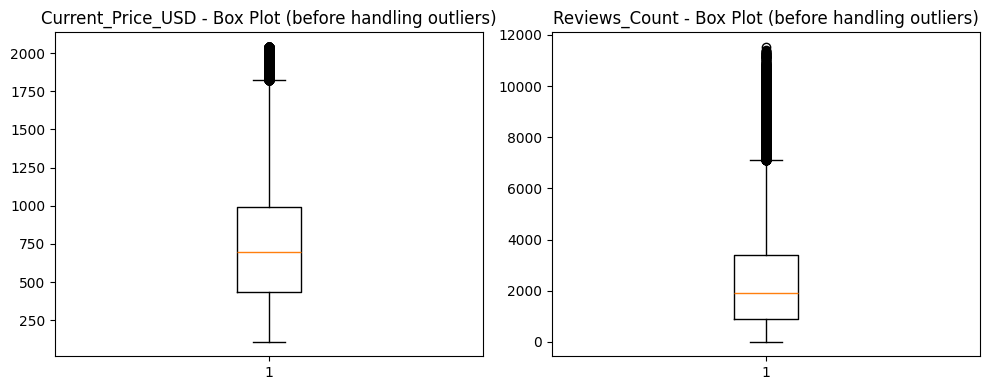

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(df_clean['Current_Price_USD'])
axes[0].set_title('Current_Price_USD - Box Plot (before handling outliers)')
axes[1].boxplot(df_clean['Reviews_Count'])
axes[1].set_title('Reviews_Count - Box Plot (before handling outliers)')
plt.tight_layout()
plt.show()


## Handle outliers

`Reviews_Count` has a long right tail (a few very popular listings with thousands of reviews). We **cap (winsorize)** these instead of deleting rows, keeping the data but limiting the influence of extreme values.


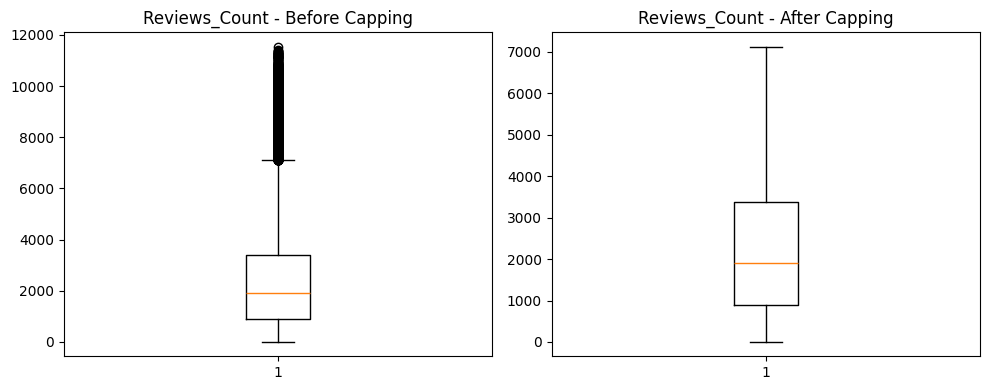

Reviews_Count stats before capping:
 count    80000.000000
mean      2405.995925
std       1973.630852
min         10.000000
25%        896.000000
50%       1893.500000
75%       3383.000000
max      11526.000000
Name: Reviews_Count, dtype: float64

Reviews_Count stats after capping:
 count    80000.000000
mean      2366.389500
std       1855.433886
min         10.000000
25%        896.000000
50%       1893.500000
75%       3383.000000
max       7113.500000
Name: Reviews_Count_capped, dtype: float64


In [9]:
df_clean['Reviews_Count_capped'] = df_clean['Reviews_Count'].clip(lower=reviews_lower, upper=reviews_upper)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(df_clean['Reviews_Count'])
axes[0].set_title('Reviews_Count - Before Capping')
axes[1].boxplot(df_clean['Reviews_Count_capped'])
axes[1].set_title('Reviews_Count - After Capping')
plt.tight_layout()
plt.show()

print("Reviews_Count stats before capping:\n", df_clean['Reviews_Count'].describe())
print("\nReviews_Count stats after capping:\n", df_clean['Reviews_Count_capped'].describe())


## Convert categorical variables into numerical form

- **Label Encoding** on `Condition` (binary: New vs Renewed/Refurbished).
- **One-Hot Encoding** on `Platform` and `Product_Category` (no ordinal relationship between them).


In [10]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding
le = LabelEncoder()
df_clean['Condition_encoded'] = le.fit_transform(df_clean['Condition'])
print("Label encoding mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# One-Hot Encoding
df_clean = pd.get_dummies(df_clean, columns=['Platform', 'Product_Category'], prefix=['Platform', 'Category'])

display(df_clean[[c for c in df_clean.columns if c.startswith('Platform_') or c.startswith('Category_') or c == 'Condition_encoded']].head())


Label encoding mapping: {'New': np.int64(0), 'Renewed/Refurbished': np.int64(1)}


,Condition_encoded,Platform_Amazon,Platform_Flipkart,Category_Mac,Category_Watch,Category_iPad,Category_iPhone
0,0,False,True,False,True,False,False
1,0,False,True,False,True,False,False
2,0,True,False,False,True,False,False
3,0,True,False,False,True,False,False
4,0,True,False,False,True,False,False


##Feature scaling

- **Min-Max Normalization** on `Current_Price_USD` -> scales to [0, 1].
- **Standardization (Z-score)** on `Reviews_Count_capped` -> mean 0, std 1.


In [11]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

minmax_scaler = MinMaxScaler()
df_clean['price_minmax'] = minmax_scaler.fit_transform(df_clean[['Current_Price_USD']])

standard_scaler = StandardScaler()
df_clean['reviews_zscore'] = standard_scaler.fit_transform(df_clean[['Reviews_Count_capped']])

display(df_clean[['Current_Price_USD', 'price_minmax', 'Reviews_Count_capped', 'reviews_zscore']].head())


,Current_Price_USD,price_minmax,Reviews_Count_capped,reviews_zscore
0,435.81,0.168934,40.0,-1.253833
1,436.49,0.169286,84.0,-1.230119
2,422.73,0.162153,110.0,-1.216106
3,425.00,0.163330,111.0,-1.215567
4,436.22,0.169146,35.0,-1.256528


## Feature selection via correlation analysis, and correlation heatmap

In [12]:
numeric_df = df_clean.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

print("Correlation of each feature with 'Rating':")
print(corr_matrix['Rating'].sort_values(ascending=False))


Correlation of each feature with 'Rating':
Rating                  1.000000
Current_Price_INR       0.162714
price_minmax            0.110571
Current_Price_USD       0.110571
Reviews_Count           0.003413
Reviews_Count_capped    0.002732
reviews_zscore          0.002732
Launch_Price_USD       -0.001760
Launch_Price_INR       -0.001760
Discount_Pct           -0.310257
Condition_encoded      -0.643662
Name: Rating, dtype: float64


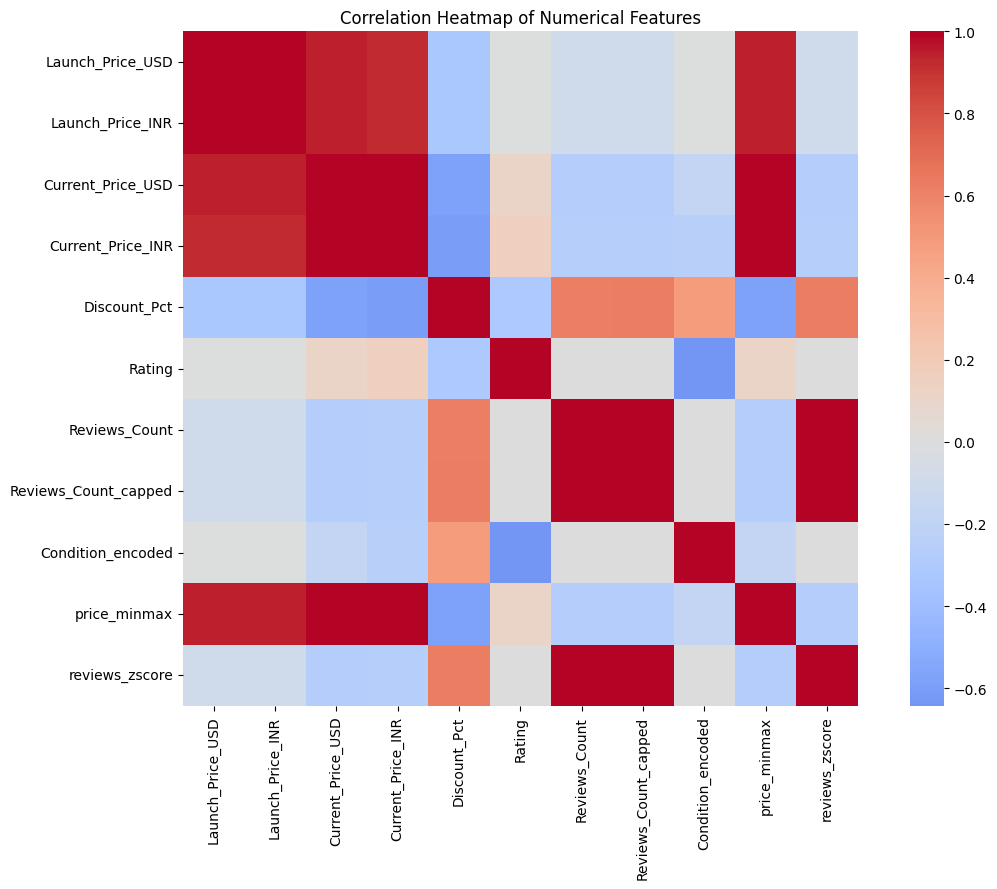

In [13]:
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()


**Interpretation:** `Launch_Price_USD` and `Current_Price_USD` are (unsurprisingly) very highly correlated with each other, since current price is derived from launch price minus a discount — so for modeling purposes we would typically keep only one, or use `Discount_Pct` instead to avoid redundancy. `Rating` shows relatively weak correlation with the price-related features, suggesting price alone doesn't explain customer satisfaction in this dataset.

##Feature engineering — new features from existing attributes

In [14]:
# Price difference and price ratio between launch and current price
df_clean['Price_Drop_USD'] = df_clean['Launch_Price_USD'] - df_clean['Current_Price_USD']
df_clean['Price_Ratio'] = df_clean['Current_Price_USD'] / df_clean['Launch_Price_USD']

# Whether a sale event was active
df_clean['On_Sale'] = (df_clean['Sale_Event'] != 'No Sale').astype(int)

# USD-to-INR implied exchange rate for that row (sanity/analysis feature)
df_clean['Implied_FX_Rate'] = df_clean['Current_Price_INR'] / df_clean['Current_Price_USD']

display(df_clean[['Launch_Price_USD', 'Current_Price_USD', 'Price_Drop_USD', 'Price_Ratio', 'On_Sale', 'Implied_FX_Rate']].head())


,Launch_Price_USD,Current_Price_USD,Price_Drop_USD,Price_Ratio,On_Sale,Implied_FX_Rate
0,429,435.81,-6.81,1.015874,0,99.406645
1,429,436.49,-7.49,1.017459,0,96.956242
2,429,422.73,6.27,0.985385,0,96.703238
3,429,425.00,4.00,0.990676,0,98.844000
4,429,436.22,-7.22,1.016830,0,96.245656


##Convert data types wherever necessary

In [15]:
# Date is currently a string -> convert to datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

# Extract useful datetime components now that it's a proper datetime type
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month

# Stock_Status and Condition are categorical labels -> convert to 'category' dtype
df_clean['Stock_Status'] = df_clean['Stock_Status'].astype('category')
df_clean['Condition'] = df_clean['Condition'].astype('category')

print(df_clean[['Date', 'Year', 'Month', 'Stock_Status', 'Condition']].dtypes)


Date            datetime64[ns]
Year                     int32
Month                    int32
Stock_Status          category
Condition             category
dtype: object


##Handle inconsistent and noisy data

In [16]:
# Check for inconsistent text categories (mismatched casing/whitespace)
print("Unique Model_Name sample:", df_clean['Model_Name'].unique()[:5])

# Standardize text columns: strip whitespace (casing kept as-is since Model_Name is a proper noun)
text_cols = df_clean.select_dtypes(include=['object']).columns
for col in text_cols:
    df_clean[col] = df_clean[col].str.strip()

# Sanity-check: discounted price should never exceed the launch price by an implausible margin,
# and discount percentage should be within a sane range
noisy_rows = df_clean[(df_clean['Current_Price_USD'] <= 0) | (df_clean['Discount_Pct'] < -50) | (df_clean['Discount_Pct'] > 100)]
print("\nRows with implausible price/discount values:", len(noisy_rows))


Unique Model_Name sample: ['Apple Watch Series 6 (44mm)' 'iPad Air (4th Gen) 64GB' 'iPhone 12 64GB'
 'iPhone 12 Pro 128GB' 'MacBook Air M1 256GB']

Rows with implausible price/discount values: 0


## Split the dataset into training and testing sets

In [17]:
from sklearn.model_selection import train_test_split

feature_cols = ['price_minmax', 'reviews_zscore', 'Condition_encoded', 'Price_Ratio', 'On_Sale']
X = df_clean[feature_cols]
y = df_clean['Stock_Status'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nClass balance in training set:\n", y_train.value_counts())


Training set shape: (64000, 5)
Testing set shape: (16000, 5)

Class balance in training set:
 Stock_Status
In Stock        44027
Out of Stock    10780
Low Stock        9193
Name: count, dtype: int64


## Data balancing (Random Oversampling / SMOTE)

We predict `Stock_Status` (In Stock / Out of Stock / Low Stock), which is imbalanced since most listings are in stock. We balance the training set two ways for comparison.


In [18]:
from imblearn.over_sampling import RandomOverSampler, SMOTE

print("Before balancing:", y_train.value_counts().to_dict())

# Random Oversampling
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
print("After Random Oversampling:", y_train_ros.value_counts().to_dict())

# SMOTE (synthetic samples rather than exact duplicates)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("After SMOTE:", y_train_smote.value_counts().to_dict())


Before balancing: {'In Stock': 44027, 'Out of Stock': 10780, 'Low Stock': 9193}
After Random Oversampling: {'In Stock': 44027, 'Out of Stock': 44027, 'Low Stock': 44027}
After SMOTE: {'In Stock': 44027, 'Out of Stock': 44027, 'Low Stock': 44027}


## Visualize distributions before and after preprocessing

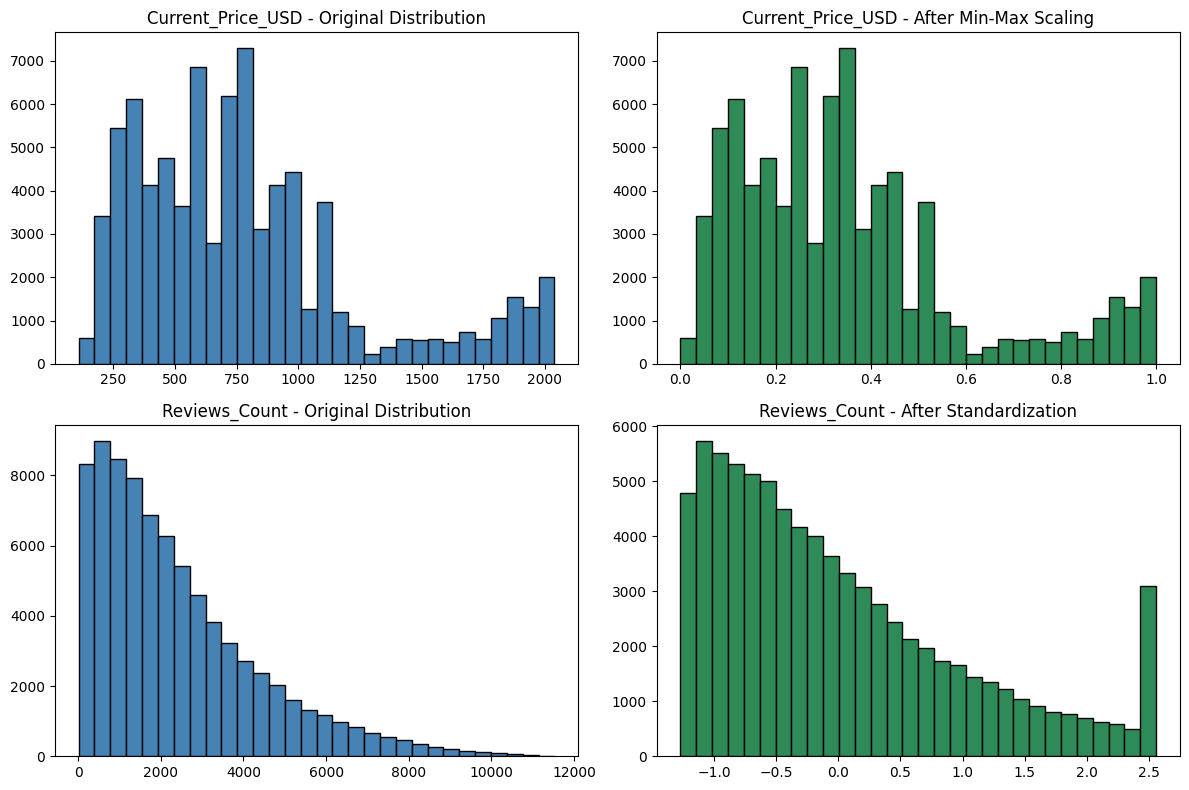

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df['Current_Price_USD'].dropna(), bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Current_Price_USD - Original Distribution')

axes[0, 1].hist(df_clean['price_minmax'], bins=30, color='seagreen', edgecolor='black')
axes[0, 1].set_title('Current_Price_USD - After Min-Max Scaling')

axes[1, 0].hist(df['Reviews_Count'].dropna(), bins=30, color='steelblue', edgecolor='black')
axes[1, 0].set_title('Reviews_Count - Original Distribution')

axes[1, 1].hist(df_clean['reviews_zscore'], bins=30, color='seagreen', edgecolor='black')
axes[1, 1].set_title('Reviews_Count - After Standardization')

plt.tight_layout()
plt.show()


## Compare dataset before and after preprocessing

In [20]:
comparison = pd.DataFrame({
    'Aspect': ['Rows', 'Columns', 'Missing values', 'Duplicate rows',
               'Reviews_Count outliers (IQR)', 'Categorical columns encoded', 'Features scaled'],
    'Before': [df.shape[0], df.shape[1], df.isnull().sum().sum(), df.duplicated().sum(),
               len(reviews_outliers), 0, 0],
    'After': [df_clean.shape[0], df_clean.shape[1], df_clean.isnull().sum().sum(), 0,
              0, 3, 2]
})
display(comparison)


,Aspect,Before,After
0,Rows,80000,80000
1,Columns,14,28
2,Missing values,73351,0
3,Duplicate rows,0,0
4,Reviews_Count outliers (IQR),2628,0
5,Categorical columns encoded,0,3
6,Features scaled,0,2


##  Save the cleaned dataset as a new CSV file

In [21]:
df_clean.to_csv('apple_products_pricing_preprocessed.csv', index=False)
print("Saved cleaned dataset to 'apple_products_pricing_preprocessed.csv'")
print("Final shape:", df_clean.shape)

# If running in Colab, uncomment to download the file to your computer:
# from google.colab import files
# files.download('apple_products_pricing_preprocessed.csv')


Saved cleaned dataset to 'apple_products_pricing_preprocessed.csv'
Final shape: (80000, 28)


## Documentation summary

Every preprocessing step above has been documented inline with markdown explanations and code outputs, covering:

| # | Step | Technique used |
|---|------|-----------------|
| 1-3 | Load & inspect data | `pandas`, `.info()`, `.head()/.tail()/.sample()` |
| 4 | Missing values | Explicit "No Sale" category for meaningful missingness |
| 5 | Duplicates | `.drop_duplicates()` |
| 6-7 | Outliers | IQR & Z-score detection, capping (winsorization) |
| 8 | Categorical encoding | Label Encoding, One-Hot Encoding |
| 9 | Feature scaling | Min-Max Normalization, Standardization |
| 10-11 | Feature selection | Correlation matrix & heatmap |
| 12 | Feature engineering | `Price_Drop_USD`, `Price_Ratio`, `On_Sale`, `Implied_FX_Rate` |
| 13 | Data type conversion | `.astype()`, `pd.to_datetime()` |
| 14 | Noisy/inconsistent data | Text whitespace cleanup, sanity checks |
| 15 | Train/test split | `train_test_split` |
| 16 | Data balancing | Random Oversampling, SMOTE |
| 17-18 | Visualization & comparison | Histograms, summary table |
| 19 | Save output | `.to_csv()` |

This notebook, along with the saved `apple_products_pricing_preprocessed.csv`, should be pushed to a GitHub repository as required by the lab exercise.
